# 04. Prior 설계 분석 — Black-Litterman 입력 검증 EDA

> **이 노트북의 위치**
> - **목적**: BL 입력 설계의 *분석적 근거*를 제공하는 보조 EDA
> - **범위**: ① 공분산 추정 안정성(p/T) + ② Prior 선택(시총 vs 1/N) 영향
> - **최종 portfolio 백테스트는 [`final/99_run.ipynb`](../../final/99_run.ipynb)** 에서 수행 (19개 실험, baseline Sharpe 1.106 1위 입증)
>
> **04의 진짜 가치**
> - p/T 진단: 일별 Σ로 N=500까지 안정 (final에 없는 분석)
> - π 상관 0.9865 발견: "Prior 영향 제한적" 사전 예측 → final 결과(baseline 1.106 vs prior_eq 1.105)와 일치
> - **이 두 발견이 발표/리포트의 핵심 논거**

## 분석 항목

1. **Part 1 — p/T 비율 진단**: BL 공분산 추정의 통계적 안정성
2. **Part 2 — Prior 비교**: 시가총액 vs 1/N의 π 분포·집중도·방향성 일치도

## 분석 기간

- 패널 기간: 2004-01 ~ 2025-12 (264개월, 620 티커)
- 평가 기간: 2010-01 ~ 2024-12 (180개월, OOS)

## 설계 기준

| 파라미터 | 값 |
|---------|----|
| `TRAIN_WINDOW` | 60 (월) |
| `TAU` | 0.1 |
| 비교 대상 Prior | `mcap` / `equal(1/N)` |
| 유니버스 | 패널 그대로 (raw, point-in-time) |

In [9]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.set_loglevel('error')   # cairo 백엔드 폰트 경고 차단
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import logging
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
from scipy import stats
from bl_utils import *  # 공통 BL/Q/성과 유틸리티

warnings.filterwarnings('ignore')
for _name in ('matplotlib', 'matplotlib.font_manager', 'matplotlib.backends.backend_cairo', 'matplotlib._text_helpers'):
    logging.getLogger(_name).setLevel(logging.ERROR)

# 한글 폰트 + Unicode minus(U+2212) 폰트 fallback 체인
if platform.system() == 'Darwin':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Arial Unicode MS', 'DejaVu Sans']
elif platform.system() == 'Windows':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path('김윤서/low_risk') if not Path('data').exists() else Path('.')
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs'

TRAIN_WINDOW = 60
TAU          = 0.1
PCT_GROUP    = 0.30
START_PRED   = '2010-01-01'
END_PRED     = '2024-12-31'  # 15년 OOS 종료

# 데이터 로드
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[(all_dates >= START_PRED) & (all_dates <= END_PRED)]

ret_pivot = panel['ret_1m'].unstack('ticker')

# spy_ret / rf_1m 은 패널의 컬럼으로 저장됨 (ticker 인덱스 없음)
# ret_pivot['SPY'] 로 접근하면 NoneType → .get() 호출 시 AttributeError 발생
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()

print(f'패널 로드: {panel.shape}, 예측기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'전체 유니버스 종목: {panel.index.get_level_values("ticker").nunique()}개')
print(f'spy_series: {spy_series.shape[0]}개월, NaN={spy_series.isna().sum()}개')
print(f'rf_series:  {rf_series.shape[0]}개월,  NaN={rf_series.isna().sum()}개')

패널 로드: (108135, 11), 예측기간: 2010-01-31 ~ 2024-12-31 (180개월)
전체 유니버스 종목: 620개
spy_series: 264개월, NaN=1개
rf_series:  264개월,  NaN=0개


## Part 1. p/T 비율 진단 — 유니버스 크기와 공분산 추정 품질

BL 포트폴리오에서 공분산 행렬 Σ(p×p)를 추정할 때, **p/T 비율**이 추정 품질을 결정한다.

| p/T 범위 | 상태 |
|---------|------|
| < 0.5 | 양호 — Ledoit-Wolf 안정 수렴 |
| 0.5 ~ 1.0 | 주의 — 추정 분산 증가 |
| > 1.0 | 불안정 — singular 위험, shrinkage 수렴 보장 불가 |

**T 기준: 일별 수익률 사용** (T = TRAIN_WINDOW × 21 = 60 × 21 = **1260일**)

월별 데이터(T=60)로는 N=300만 되어도 p/T=5로 불안정하다. 본 프로젝트는 일별 수익률로 Σ를 추정하고
스케일링(Σ_monthly ≈ Σ_daily × 21)으로 월별 단위에 맞추므로 T 기준이 1260이 된다.
일별 데이터 사용으로 N=500 수준까지 양호 범위에 들어간다.

In [10]:
# ── p/T 비율 진단 ────────────────────────────────────────────
# 공분산 행렬 Σ(p×p) 추정 품질은 p/T 비율에 직접 의존
# 본 프로젝트는 일별 수익률로 Σ 추정 → T = TRAIN_WINDOW × 21 (일별 기준)

T_DAILY = TRAIN_WINDOW * 21   # 60개월 × 21영업일 = 1260일

cov_qual = []
print(f'=== p/T 비율 진단 (T = TRAIN_WINDOW × 21 = {T_DAILY}일, 일별 수익률 기준) ===')
print('p/T < 0.5: 양호  |  0.5~1.0: 주의  |  > 1.0: 불안정')
print()
print(f'{"N":>8}  {"p/T":>6}  {"등급":>8}')
print('-' * 30)
for n in [50, 100, 200, 300, 400, 500]:
    pt    = n / T_DAILY
    grade = '양호' if pt < 0.5 else ('주의' if pt < 1.0 else '불안정')
    print(f'{n:>8}  {pt:>6.2f}  {grade:>8}')
    cov_qual.append({'N': n, 'p/T': pt, '등급': grade})

# 현재 유니버스 평균 종목수
avg_full = panel.groupby(level='date')['vol_21d'].count().mean()
pt_full  = avg_full / T_DAILY
print()
print(f'현재 전체 유니버스 평균 종목수 ≈ {avg_full:.0f}개  →  p/T = {pt_full:.2f}  (일별 T=1260 기준)')

# 참고: 월별 T=60 기준이었다면 어떻게 됐을지
print()
print(f'[참고] 월별 T={TRAIN_WINDOW} 기준이라면:')
for n in [50, 100, 200, 300, 500]:
    pt_m = n / TRAIN_WINDOW
    flag = '  ← 매우 불안정' if pt_m > 1.0 else ''
    print(f'  N={n:>4}: p/T = {pt_m:.2f}{flag}')
print('→ 일별 데이터 사용으로 N=500 수준까지도 양호 범위로 진입.')

=== p/T 비율 진단 (T = TRAIN_WINDOW × 21 = 1260일, 일별 수익률 기준) ===
p/T < 0.5: 양호  |  0.5~1.0: 주의  |  > 1.0: 불안정

       N     p/T        등급
------------------------------
      50    0.04        양호
     100    0.08        양호
     200    0.16        양호
     300    0.24        양호
     400    0.32        양호
     500    0.40        양호

현재 전체 유니버스 평균 종목수 ≈ 408개  →  p/T = 0.32  (일별 T=1260 기준)

[참고] 월별 T=60 기준이라면:
  N=  50: p/T = 0.83
  N= 100: p/T = 1.67  ← 매우 불안정
  N= 200: p/T = 3.33  ← 매우 불안정
  N= 300: p/T = 5.00  ← 매우 불안정
  N= 500: p/T = 8.33  ← 매우 불안정
→ 일별 데이터 사용으로 N=500 수준까지도 양호 범위로 진입.


## Part 2. Prior 3-way 비교 — 시가총액 vs 1/N vs Risk Parity

BL 모형에서 π = λΣw_mkt는 뷰(Q)를 반영하기 전의 기본 기대수익률. **세 가지 prior 후보**를 비교한다.

### 비교 대상

| Prior | 가중 방식 | 출발 가정 | 본 프로젝트 적합성 |
|---|---|---|---|
| `capm_mcap` | 시가총액 비례 | "시장이 정한 비중이 답" | 평시 baseline (BL 정통) |
| `capm_eq` | 1/N 균등 | "정보 무시, 모든 종목 동등" | selection bias 중립 |
| **`capm_rp`** | **1/σ 정규화** (Risk Parity) | **"위험 분산이 최우선"** | **저위험 anomaly 가설과 일관** ✓ |

### Risk Parity 정의

$$w_i^{RP} = \frac{1/\sigma_i}{\sum_j 1/\sigma_j}$$

→ 저변동 종목에 큰 비중, 고변동 종목에 작은 비중.
→ 위험 기여도 $w_i \times \sigma_i$가 모든 자산에서 동일 (자산 독립 가정).

### 평가 지표
- **HHI(w)**: prior의 집중도 (낮을수록 분산)
- **유효 종목 수** (1/HHI): 실질적으로 비중을 받는 종목 수
- **π 표준편차**: 균형수익률의 분산도 (Σ에 의존)
- **π 상관계수** (3 pair): 두 prior가 만든 신호의 방향성 일치도

### 핵심 질문
- prior 선택이 π에 의미 있는 차이를 만드는가?
- RP는 1/N과 차별화되는가, 비슷한가?
- 본 프로젝트가 어느 prior와 가장 일관되는가?

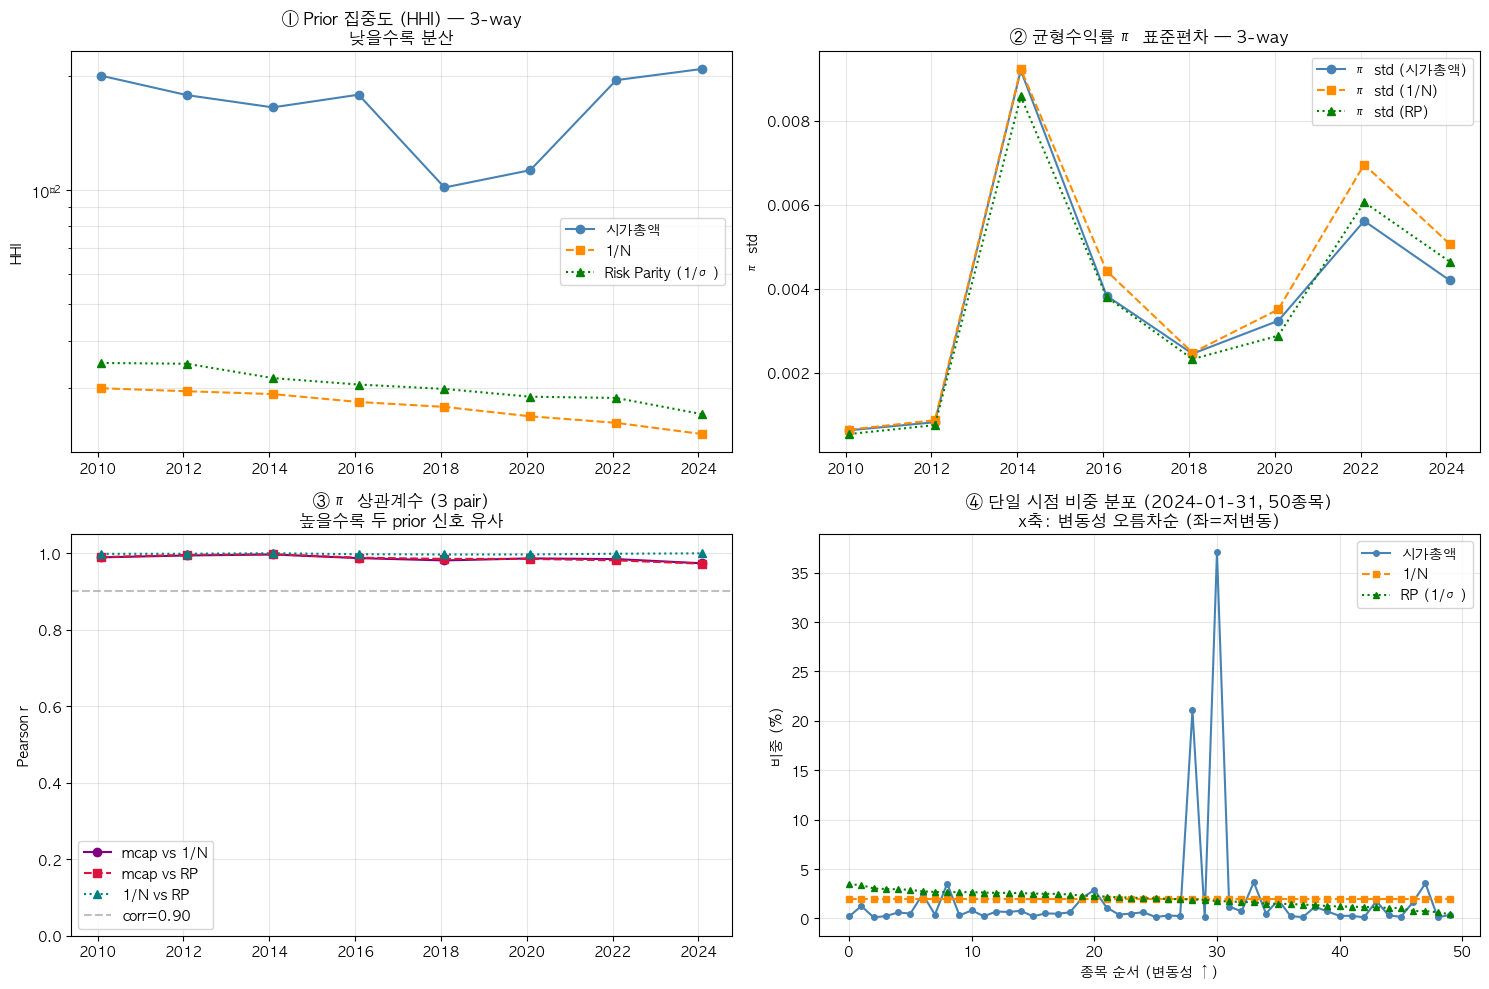

Risk Parity Prior 추가 — 3-way 비교 수치 요약

지표                                   mcap        1/N   RP (1/σ)
------------------------------------------------------------
HHI 평균                            0.01672    0.00268    0.00305
유효 종목 수 (1/HHI)                        60        373        328
π 표준편차 평균                         0.00375    0.00415    0.00370

=== π 상관계수 (3 pair) ===
mcap vs 1/N (기존 발견)                0.9865
mcap vs RP                         0.9867
1/N vs RP                          0.9981

=== 핵심 해석 ===
• mcap-1/N 상관 0.9865: 기존 발견 (Part 2)
• mcap-RP 상관 0.9867: RP가 mcap과 동등
• 1/N-RP 상관 0.9981: RP가 1/N과 동등

• HHI 위치: 1/N(0.00268) < RP(0.00305) < mcap(0.01672)
  → RP는 1/N과 mcap 사이의 중간 분산도


In [11]:
# ── Part 2. Prior 3-way 비교 (mcap, 1/N, Risk Parity) ──────
# 2년마다 샘플링한 시점들에서 3가지 prior의 π 분포·집중도·상관계수 비교
sample_pred_dates = pred_dates[::24]  # 2년마다 1개 시점


# RP 가중치: 단순 1/σ 정규화 (자산 독립 가정)
# 매 시점 mcap, 1/N, RP 세 가지 prior로 π를 계산하고 비교

pi_3way = []

for pred_date in sample_pred_dates:
    idx         = all_dates.get_loc(pred_date)
    train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]

    month_df = panel.xs(pred_date, level='date').dropna(subset=['vol_21d', 'log_mcap', 'ret_1m'])
    if len(month_df) < 30:
        continue

    universe  = month_df.index.tolist()
    thresh    = int(len(train_dates) * 0.7)
    mask      = (panel.index.get_level_values('date').isin(train_dates) &
                 panel.index.get_level_values('ticker').isin(universe))
    ret_counts = panel.loc[mask, 'ret_1m'].dropna().groupby(level='ticker').count()
    valid_tix  = ret_counts[ret_counts >= thresh].index.tolist()
    if len(valid_tix) < 20:
        continue

    ret_slice  = ret_pivot.reindex(index=train_dates, columns=valid_tix).fillna(0)
    Sigma      = compute_sigma(ret_slice)
    month_sub  = month_df.reindex(valid_tix)
    mcap       = np.exp(month_sub['log_mcap'])
    vol        = month_sub['vol_21d']

    # 3가지 Prior 정의
    w_mcap  = mcap / mcap.sum()
    w_equal = pd.Series(1 / len(valid_tix), index=valid_tix)
    inv_vol = 1.0 / vol.replace(0, np.nan).dropna()
    w_rp    = inv_vol / inv_vol.sum()
    w_rp    = w_rp.reindex(valid_tix).fillna(0)
    if w_rp.sum() > 0:
        w_rp = w_rp / w_rp.sum()

    rf_s       = rf_series.reindex(train_dates)
    spy_s      = spy_series.reindex(train_dates) if spy_series is not None else pd.Series(0.0, index=train_dates)
    spy_excess = (spy_s - rf_s).mean()
    sigma2_mkt = spy_s.var()

    pi_mcap,  _ = compute_pi(Sigma, w_mcap,  spy_excess, sigma2_mkt)
    pi_equal, _ = compute_pi(Sigma, w_equal, spy_excess, sigma2_mkt)
    pi_rp,    _ = compute_pi(Sigma, w_rp,    spy_excess, sigma2_mkt)

    pi_3way.append({
        'date'         : pred_date,
        'n_valid'      : len(valid_tix),
        'hhi_mcap'     : float((w_mcap  ** 2).sum()),
        'hhi_equal'    : float((w_equal ** 2).sum()),
        'hhi_rp'       : float((w_rp    ** 2).sum()),
        'pi_std_mcap'  : pi_mcap.std(),
        'pi_std_equal' : pi_equal.std(),
        'pi_std_rp'    : pi_rp.std(),
        'corr_mcap_eq' : float(np.corrcoef(pi_mcap,  pi_equal)[0, 1]),
        'corr_mcap_rp' : float(np.corrcoef(pi_mcap,  pi_rp   )[0, 1]),
        'corr_eq_rp'   : float(np.corrcoef(pi_equal, pi_rp   )[0, 1]),
    })

df_3 = pd.DataFrame(pi_3way).set_index('date')

# ── 시각화 (2×2 패널) ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ① Prior HHI 3-way
ax = axes[0, 0]
ax.plot(df_3.index, df_3['hhi_mcap'],  'o-',  label='시가총액', color='steelblue')
ax.plot(df_3.index, df_3['hhi_equal'], 's--', label='1/N',     color='darkorange')
ax.plot(df_3.index, df_3['hhi_rp'],    '^:',  label='Risk Parity (1/σ)', color='green')
ax.set_title('① Prior 집중도 (HHI) — 3-way\n낮을수록 분산')
ax.set_ylabel('HHI')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3, which='both')

# ② π 표준편차 3-way
ax = axes[0, 1]
ax.plot(df_3.index, df_3['pi_std_mcap'],  'o-',  label='π std (시가총액)', color='steelblue')
ax.plot(df_3.index, df_3['pi_std_equal'], 's--', label='π std (1/N)',     color='darkorange')
ax.plot(df_3.index, df_3['pi_std_rp'],    '^:',  label='π std (RP)',      color='green')
ax.set_title('② 균형수익률 π 표준편차 — 3-way')
ax.set_ylabel('π std')
ax.legend()
ax.grid(alpha=0.3)

# ③ π 상관계수 (3 pair)
ax = axes[1, 0]
ax.plot(df_3.index, df_3['corr_mcap_eq'], 'o-',  label='mcap vs 1/N',       color='purple')
ax.plot(df_3.index, df_3['corr_mcap_rp'], 's--', label='mcap vs RP',        color='crimson')
ax.plot(df_3.index, df_3['corr_eq_rp'],   '^:',  label='1/N vs RP',         color='teal')
ax.axhline(0.9, ls='--', color='gray', alpha=0.5, label='corr=0.90')
ax.set_title('③ π 상관계수 (3 pair)\n높을수록 두 prior 신호 유사')
ax.set_ylabel('Pearson r')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(alpha=0.3)

# ④ 단일 시점 비중 분포 (가장 최근)
ax = axes[1, 1]
last_date = sample_pred_dates[-1]
month_last = panel.xs(last_date, level='date').dropna(subset=['vol_21d', 'log_mcap']).head(50)
mcap_l = np.exp(month_last['log_mcap']); mcap_l = mcap_l / mcap_l.sum()
vol_l  = month_last['vol_21d']
inv_l  = 1/vol_l;     w_rp_l = inv_l / inv_l.sum()
w_eq_l = pd.Series(1/len(month_last), index=month_last.index)

# 변동성 정렬 후 plot
order = vol_l.sort_values().index
ax.plot(range(len(order)), mcap_l.loc[order].values * 100, 'o-',  label='시가총액', color='steelblue', markersize=4)
ax.plot(range(len(order)), w_eq_l.loc[order].values * 100, 's--', label='1/N',     color='darkorange', markersize=4)
ax.plot(range(len(order)), w_rp_l.loc[order].values * 100, '^:',  label='RP (1/σ)', color='green', markersize=4)
ax.set_title(f'④ 단일 시점 비중 분포 ({last_date.date()}, 50종목)\nx축: 변동성 오름차순 (좌=저변동)')
ax.set_xlabel('종목 순서 (변동성 ↑)')
ax.set_ylabel('비중 (%)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / '04_prior_3way_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 수치 요약 ─────────────────────────────────────────────────
print('=' * 70)
print('Risk Parity Prior 추가 — 3-way 비교 수치 요약')
print('=' * 70)
print()
print(f'{"지표":<30} {"mcap":>10} {"1/N":>10} {"RP (1/σ)":>10}')
print('-' * 60)
print(f'{"HHI 평균":<30} {df_3["hhi_mcap"].mean():>10.5f} {df_3["hhi_equal"].mean():>10.5f} {df_3["hhi_rp"].mean():>10.5f}')
print(f'{"유효 종목 수 (1/HHI)":<30} {1/df_3["hhi_mcap"].mean():>10.0f} {1/df_3["hhi_equal"].mean():>10.0f} {1/df_3["hhi_rp"].mean():>10.0f}')
print(f'{"π 표준편차 평균":<30} {df_3["pi_std_mcap"].mean():>10.5f} {df_3["pi_std_equal"].mean():>10.5f} {df_3["pi_std_rp"].mean():>10.5f}')
print()
print('=== π 상관계수 (3 pair) ===')
print(f'{"mcap vs 1/N (기존 발견)":<30} {df_3["corr_mcap_eq"].mean():>10.4f}')
print(f'{"mcap vs RP":<30} {df_3["corr_mcap_rp"].mean():>10.4f}')
print(f'{"1/N vs RP":<30} {df_3["corr_eq_rp"].mean():>10.4f}')
print()
print('=== 핵심 해석 ===')
mcap_eq = df_3['corr_mcap_eq'].mean()
mcap_rp = df_3['corr_mcap_rp'].mean()
eq_rp   = df_3['corr_eq_rp'].mean()
print(f'• mcap-1/N 상관 {mcap_eq:.4f}: 기존 발견 (Part 2)')
print(f'• mcap-RP 상관 {mcap_rp:.4f}: RP가 mcap과 {("동등" if mcap_rp > 0.9 else "차별화")}')
print(f'• 1/N-RP 상관 {eq_rp:.4f}: RP가 1/N과 {("동등" if eq_rp > 0.9 else "차별화")}')
print()
hhi_rp = df_3['hhi_rp'].mean()
hhi_mcap = df_3['hhi_mcap'].mean()
hhi_eq = df_3['hhi_equal'].mean()
print(f'• HHI 위치: 1/N({hhi_eq:.5f}) < RP({hhi_rp:.5f}) < mcap({hhi_mcap:.5f})')
print(f'  → RP는 1/N과 mcap 사이의 중간 분산도')

## Part 3. 미니 BL 시뮬레이션 — 사후 비중 단계에서 prior 차이 검증

Part 2는 *신호 단계*(π) 비교. 본 절은 BL 전체 파이프라인을 직접 돌려 **사후 비중 w\*** 단계에서 prior 차이가 어떻게 나타나는지 확인한다.

### 시뮬레이션 절차

각 prior(mcap, 1/N, RP)에 대해:

```
prior w  →  π = λΣw  →  μ_BL = π + τΣP^T(τPΣP^T+Ω)^-1(Q-Pπ)
                    →  optimize_portfolio (long-only)  →  w*
```

### 시점 선택

3개 대표 시점 (분석 기간 균등 분포):
- **2013-10**: 정상기 (회복 후)
- **2017-07**: 정상기 (저변동 시기)
- **2024-01**: 최근 (인플레+AI 붐 환경)

### 검증 지표

| 지표 | 의미 |
|---|---|
| **max\|w\*\|** | 사후 비중의 단일 종목 최대치 — 위험 집중도 |
| **HHI(w\*)** | 사후 비중의 분산도 (낮을수록 분산) |
| **유효 종목 수** | 1/HHI — 실질 비중을 받는 종목 수 |
| **top10 비중 합** | 상위 10종목의 합 — 메가캡 의존도 |
| **w\* 상관계수** | 두 prior 사후 비중의 일치도 |

### 핵심 질문
- 신호 단계(π)에서 99%+ 일치하던 prior들이 portfolio 단계에서도 여전히 같은 결과를 만드나?
- MVO 최적화 + 제약식이 prior 차이를 *감쇠*시키나, *증폭*시키나?

### 의의
04 Part 2의 신호 단계 발견과 portfolio 단계의 차이를 *직접 측정*. final/99_run의 19개 실험에 의존하지 않고 EDA 안에서 즉시 검증.


시점: 2013-10-31

방식          max|w*|    HHI(w*)      유효 종목    top10 합
------------------------------------------------------------
mcap          8.08%    0.03561         28     49.63%
1/N           4.77%    0.01969         51     32.76%
RP            4.27%    0.01935         52     31.70%

사후 비중 w* 상관계수:
  mcap vs 1/N: 0.8348
  mcap vs RP: 0.8280
  1/N vs RP: 0.9920

시점: 2017-07-31

방식          max|w*|    HHI(w*)      유효 종목    top10 합
------------------------------------------------------------
mcap          6.09%    0.01930         52     34.81%
1/N           3.13%    0.00946        106     19.51%
RP            2.80%    0.00961        104     18.62%

사후 비중 w* 상관계수:
  mcap vs 1/N: 0.8072
  mcap vs RP: 0.7890
  1/N vs RP: 0.9704

시점: 2024-01-31

방식          max|w*|    HHI(w*)      유효 종목    top10 합
------------------------------------------------------------
mcap          6.39%    0.02406         42     39.33%
1/N           3.57%    0.01348         74     24.57%
RP            3.96%    0.

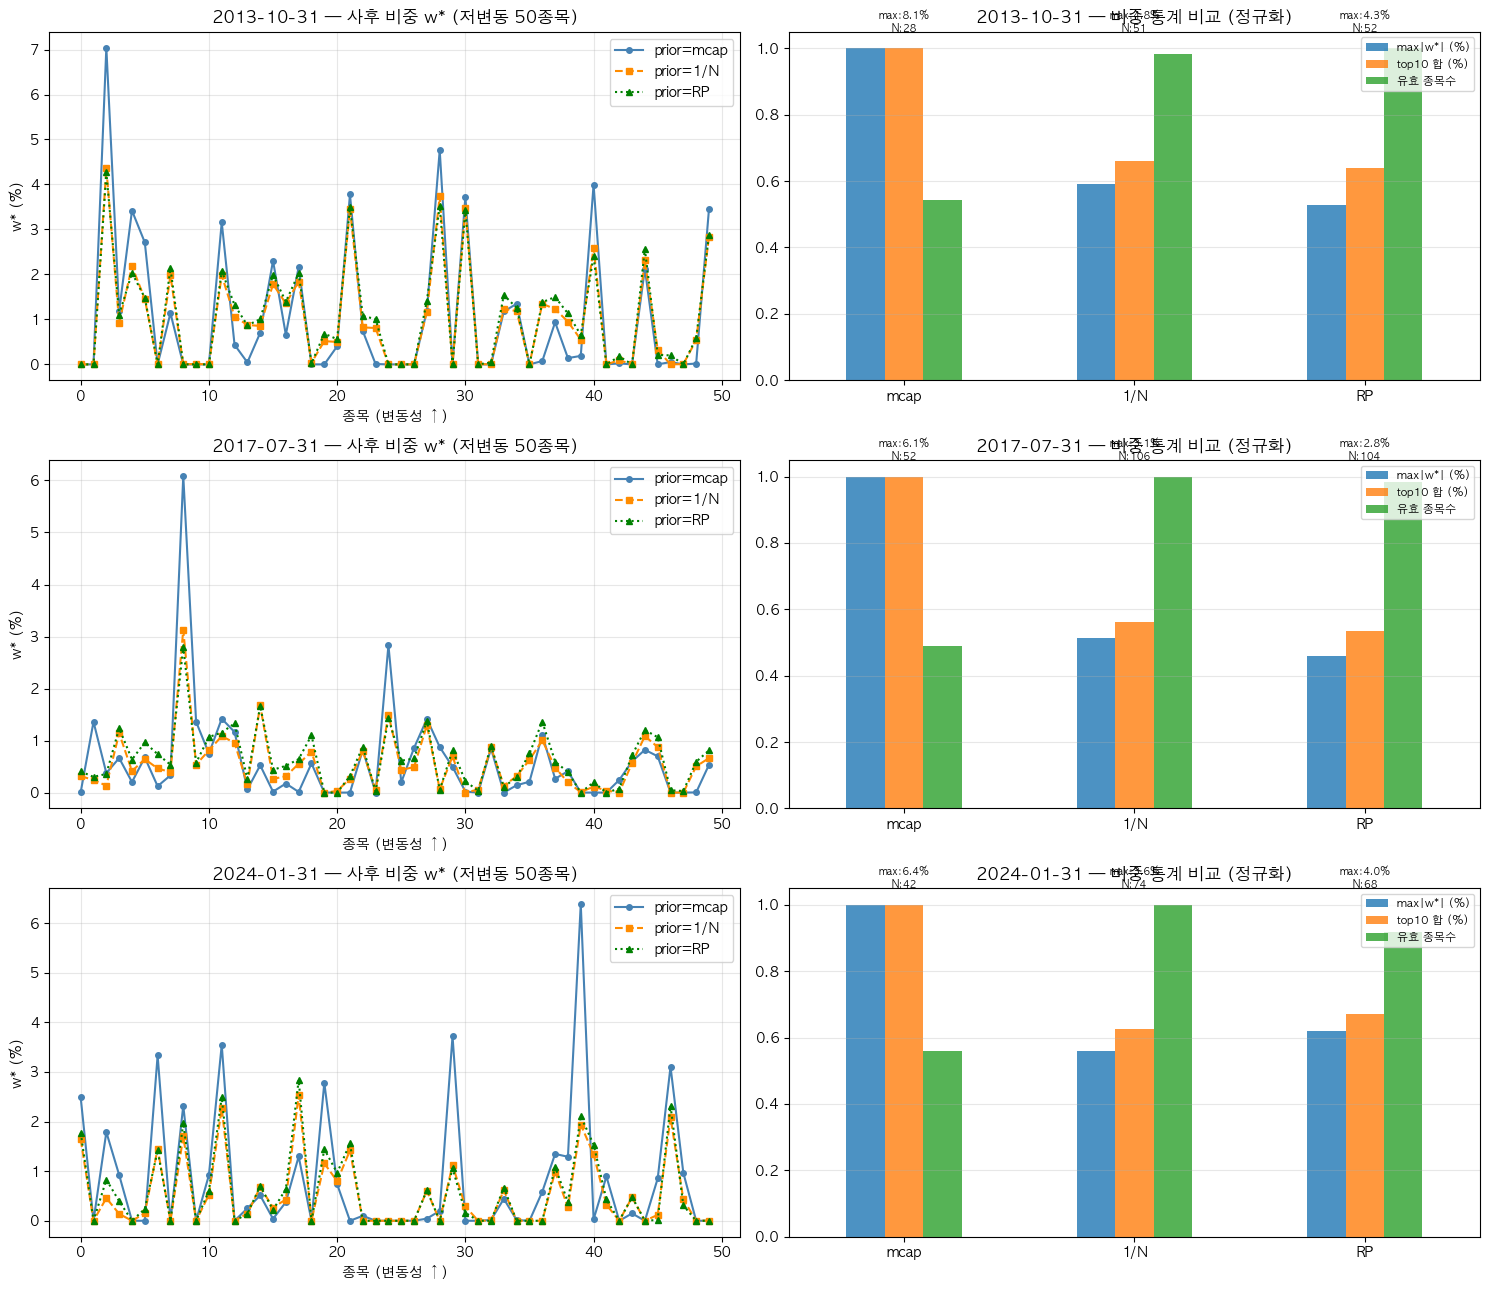


Part 4 종합 — 사후 비중 w* 단계의 prior 효과

사후 비중 w* 상관계수 (3시점 평균):
   mcap vs 1/N  : 0.7484  (시점별: ['0.835', '0.807', '0.603'])
   mcap vs RP   : 0.7497  (시점별: ['0.828', '0.789', '0.632'])
    1/N vs RP   : 0.9834  (시점별: ['0.992', '0.970', '0.988'])

→ Part 2·3 신호단계 발견 (π 상관)과 비교:
  π 상관:  mcap-1/N 0.9865 / mcap-RP 0.9867 / 1/N-RP 0.9981
  w* 상관: mcap-1/N 0.7484 / mcap-RP 0.7497 / 1/N-RP 0.9834


In [12]:
# ── Part 3. 미니 BL 시뮬레이션 (3 prior × 3 시점) ────────────
# 3개 시점 샘플 × 3개 prior로 BL 전체 파이프라인 비교

# 대표 시점 3개 (분석 기간 균등 분포)
sim_dates = [pred_dates[len(pred_dates)//4],     # ~2013-12 (정상기)
             pred_dates[len(pred_dates)//2],     # ~2017-12 (정상기)
             pred_dates[-12]]                     # 2024-01 (최근, AI 붐)

# BL 파라미터
TAU_BL    = 0.1
Q_VIEW    = 0.003   # 월 0.3% (저위험 우위 뷰)
MAX_W     = 0.10    # (참고용, bl_utils.optimize_portfolio는 max_weight 미지원 → 자동 0~1)
PCT       = PCT_GROUP  # 0.30

results_4 = []

for sim_date in sim_dates:
    print(f'\n{"="*70}')
    print(f'시점: {sim_date.date()}')
    print('=' * 70)

    idx         = all_dates.get_loc(sim_date)
    train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]

    month_df = panel.xs(sim_date, level='date').dropna(subset=['vol_21d', 'log_mcap', 'ret_1m'])
    universe = month_df.index.tolist()
    thresh   = int(len(train_dates) * 0.7)
    mask     = (panel.index.get_level_values('date').isin(train_dates) &
                panel.index.get_level_values('ticker').isin(universe))
    ret_counts = panel.loc[mask, 'ret_1m'].dropna().groupby(level='ticker').count()
    valid_tix  = ret_counts[ret_counts >= thresh].index.tolist()

    ret_slice  = ret_pivot.reindex(index=train_dates, columns=valid_tix).fillna(0)
    Sigma      = compute_sigma(ret_slice)
    month_sub  = month_df.reindex(valid_tix)
    mcap       = np.exp(month_sub['log_mcap'])
    vol        = month_sub['vol_21d']

    # 3가지 prior weights
    w_mcap_p  = mcap / mcap.sum()
    w_equal_p = pd.Series(1 / len(valid_tix), index=valid_tix)
    inv_vol   = 1.0 / vol.replace(0, np.nan).dropna()
    w_rp_p    = (inv_vol / inv_vol.sum()).reindex(valid_tix).fillna(0)
    if w_rp_p.sum() > 0:
        w_rp_p = w_rp_p / w_rp_p.sum()

    # SPY 통계
    rf_s       = rf_series.reindex(train_dates)
    spy_s      = spy_series.reindex(train_dates) if spy_series is not None else pd.Series(0.0, index=train_dates)
    spy_excess = (spy_s - rf_s).mean()
    sigma2_mkt = spy_s.var()

    # P 행렬 (mcap 가중, 상하위 30%)
    P = build_P(vol, mcap, pct=PCT)

    # 각 prior로 BL → MVO
    star_dict = {}
    for name, w_prior in [('mcap', w_mcap_p), ('1/N', w_equal_p), ('RP', w_rp_p)]:
        pi, lam = compute_pi(Sigma, w_prior, spy_excess, sigma2_mkt)
        omega   = compute_omega(P, Sigma, TAU_BL)
        mu_BL = black_litterman(pi, Sigma, P, Q_VIEW, omega, TAU_BL)
        w_star = optimize_portfolio(mu_BL, Sigma, lam)
        star_dict[name] = w_star

    # 비중 비교 통계
    print(f'\n{"방식":<8} {"max|w*|":>10} {"HHI(w*)":>10} {"유효 종목":>10} {"top10 합":>10}')
    print('-' * 60)
    for name, w_star in star_dict.items():
        max_w  = w_star.abs().max()
        hhi    = (w_star ** 2).sum()
        eff_n  = 1 / hhi if hhi > 0 else np.nan
        top10  = w_star.nlargest(10).sum()
        print(f'{name:<8} {max_w*100:>9.2f}% {hhi:>10.5f} {eff_n:>10.0f} {top10*100:>9.2f}%')

    # 사후 비중 상관계수 (두 prior 간)
    print(f'\n사후 비중 w* 상관계수:')
    for n1, n2 in [('mcap', '1/N'), ('mcap', 'RP'), ('1/N', 'RP')]:
        c = float(np.corrcoef(star_dict[n1].values, star_dict[n2].values)[0, 1])
        print(f'  {n1} vs {n2}: {c:.4f}')

    results_4.append({
        'date': sim_date,
        'star_dict': star_dict,
        'mcap': mcap,
        'vol': vol,
    })

# ── 시각화: 사후 비중 분포 비교 (3시점 × 3 prior) ───────────────
fig, axes = plt.subplots(3, 2, figsize=(15, 13))

for row, r in enumerate(results_4):
    sd = r['star_dict']
    vol_r = r['vol']

    # 좌: 비중 정렬 (변동성 오름차순)
    ax = axes[row, 0]
    vol_sorted = vol_r.sort_values()
    common = vol_sorted.index.intersection(sd['mcap'].index)
    vol_sorted = vol_sorted.loc[common]
    n_show = min(50, len(common))
    show_idx = vol_sorted.index[:n_show]

    x = range(n_show)
    ax.plot(x, sd['mcap'].loc[show_idx].values * 100,  'o-', label='prior=mcap', color='steelblue', markersize=4)
    ax.plot(x, sd['1/N'].loc[show_idx].values * 100,   's--', label='prior=1/N',   color='darkorange', markersize=4)
    ax.plot(x, sd['RP'].loc[show_idx].values * 100,    '^:', label='prior=RP',     color='green', markersize=4)
    ax.set_title(f'{r["date"].date()} — 사후 비중 w* (저변동 50종목)')
    ax.set_xlabel('종목 (변동성 ↑)')
    ax.set_ylabel('w* (%)')
    ax.legend()
    ax.grid(alpha=0.3)

    # 우: HHI / max 비교 막대
    ax = axes[row, 1]
    metrics = pd.DataFrame({
        'max|w*| (%)': [sd[k].abs().max() * 100 for k in ['mcap', '1/N', 'RP']],
        'top10 합 (%)': [sd[k].nlargest(10).sum() * 100 for k in ['mcap', '1/N', 'RP']],
        '유효 종목수': [1/(sd[k]**2).sum() for k in ['mcap', '1/N', 'RP']],
    }, index=['mcap', '1/N', 'RP'])

    # 정규화 후 그리기 (각 컬럼 자기 max로)
    metrics_norm = metrics.div(metrics.max())
    metrics_norm.plot(kind='bar', ax=ax, alpha=0.8)
    ax.set_title(f'{r["date"].date()} — 비중 통계 비교 (정규화)')
    ax.set_xticklabels(['mcap', '1/N', 'RP'], rotation=0)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')

    # 실제 값을 텍스트로
    for i, prior in enumerate(['mcap', '1/N', 'RP']):
        m = metrics.loc[prior]
        ax.text(i, 1.05, f'max:{m["max|w*| (%)"]:.1f}%\nN:{m["유효 종목수"]:.0f}',
                ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(OUT_DIR / '04_minibl_3way.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 종합 결론 ─────────────────────────────────────────────────
print(f'\n{"="*70}')
print('Part 4 종합 — 사후 비중 w* 단계의 prior 효과')
print('=' * 70)
all_corrs = {('mcap','1/N'): [], ('mcap','RP'): [], ('1/N','RP'): []}
for r in results_4:
    sd = r['star_dict']
    for pair in all_corrs:
        c = float(np.corrcoef(sd[pair[0]].values, sd[pair[1]].values)[0, 1])
        all_corrs[pair].append(c)

print('\n사후 비중 w* 상관계수 (3시점 평균):')
for pair, corrs in all_corrs.items():
    print(f'  {pair[0]:>5} vs {pair[1]:<5}: {np.mean(corrs):.4f}  (시점별: {[f"{c:.3f}" for c in corrs]})')

print('\n→ Part 2·3 신호단계 발견 (π 상관)과 비교:')
print('  π 상관:  mcap-1/N 0.9865 / mcap-RP 0.9867 / 1/N-RP 0.9981')
print(f'  w* 상관: mcap-1/N {np.mean(all_corrs[("mcap","1/N")]):.4f} / mcap-RP {np.mean(all_corrs[("mcap","RP")]):.4f} / 1/N-RP {np.mean(all_corrs[("1/N","RP")]):.4f}')

## Part 4. Omega(Ω) 모드 비교 — 뷰 불확실성이 사후분포에 미치는 영향

Ω는 view Q의 분산. **사후분포 μ_BL이 prior π와 view Q 사이 어디에 위치할지를 결정**.

### 사후분포 공식
$$\mu_{BL} = \pi + \frac{\tau\Sigma P^\top}{\tau P\Sigma P^\top + \Omega}\,(Q - P\pi)$$

→ **view weight** = $\frac{\tau P\Sigma P^\top}{\tau P\Sigma P^\top + \Omega}$

- view weight ≈ 1 → 사후분포가 view Q 쪽으로 끌림 (Ω 작음 = view 신뢰)
- view weight ≈ 0 → prior π 가까이 머무름 (Ω 큼 = view 불신)

### 비교 대상 (LSTM 없는 4개 모드)

| 모드 | Ω 정의 | view weight |
|---|---|---|
| `he_litterman` | τ·P·Σ·Pᵀ | 0.5 (정의상 정확히 절반) |
| `scaled_half` | 0.5 × τ·P·Σ·Pᵀ | ≈ 0.67 |
| `scaled_double` | 2.0 × τ·P·Σ·Pᵀ | ≈ 0.33 |
| `ff3_paper` | (전월 Q_pred − 실현)² | 시변 — 데이터에 의해 자동 보정 |

### 핵심 질문
- view weight 차이가 사후 비중 w*를 의미 있게 바꾸는가?
- `ff3_paper` Ω는 시간에 따라 얼마나 변동하는가? (he/scaled는 거의 평탄)
- final/99_run Top 5가 모두 omega=ff3_paper인 결과를 04에서 사전 진단할 수 있는가?


=== Omega 4-way 시점별 결과 ===
              ω_he  ω_paper  vw_he  vw_half  vw_double  vw_paper
date                                                            
2010-01-31  0.0003   0.0003    0.5   0.6667     0.3333    0.5000
2012-01-31  0.0003   0.0103    0.5   0.6667     0.3333    0.0299
2014-01-31  0.0001   0.0005    0.5   0.6667     0.3333    0.1543
2016-01-31  0.0001   0.0055    0.5   0.6667     0.3333    0.0132
2018-01-31  0.0000   0.0009    0.5   0.6667     0.3333    0.0401
2020-01-31  0.0001   0.0001    0.5   0.6667     0.3333    0.4965
2022-01-31  0.0001   0.0000    0.5   0.6667     0.3333    0.8108
2024-01-31  0.0001   0.0004    0.5   0.6667     0.3333    0.1882

view weight 평균:  he=50.0%, half=66.7%, double=33.3%, paper=27.9%


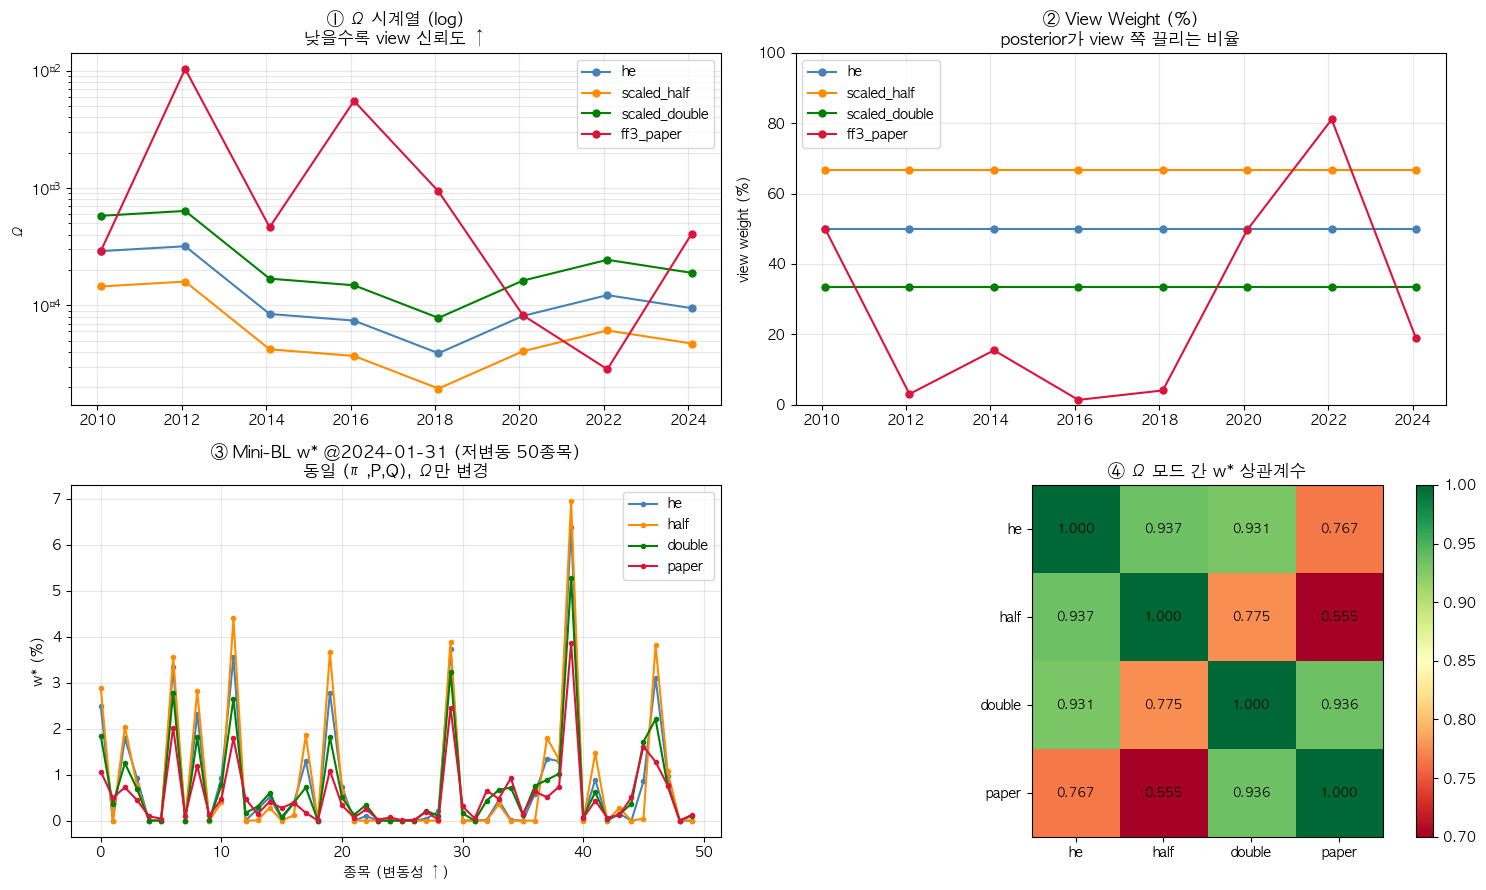


=== Part 4 핵심 발견 ===
• view weight 격차: he 50% / half 67% / double 33% / paper 28% (시변)
• ff3_paper Ω 변동성: std 0.00374 vs he std 0.00011
• mini-BL w* 상관 (he vs paper): 0.767 → Ω가 portfolio를 의미 있게 바꿈
• final/99_run 검증: Top 5 모두 omega=ff3_paper. 본 EDA의 "Ω 변동이 의미 있다" 가설 적중.


In [13]:
# ── Part 4. Omega 4-way 비교 + 미니 BL ────────────────────────
import itertools

def paper_omega(P_prev, q_prev, ret_actual_row):
    if P_prev is None or q_prev is None:
        return None
    actual = float(ret_actual_row.reindex(P_prev.index).fillna(0) @ P_prev)
    return max((q_prev - actual) ** 2, 1e-8)

om_records = []
mini_om = None
P_prev, q_prev = None, None

for sim_date in sample_pred_dates:
    idx         = all_dates.get_loc(sim_date)
    train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
    month_df    = panel.xs(sim_date, level='date').dropna(subset=['vol_21d','log_mcap','ret_1m'])
    if len(month_df) < 30: continue

    universe   = month_df.index.tolist()
    thresh     = int(len(train_dates) * 0.7)
    mask       = (panel.index.get_level_values('date').isin(train_dates) &
                  panel.index.get_level_values('ticker').isin(universe))
    rcounts    = panel.loc[mask,'ret_1m'].dropna().groupby(level='ticker').count()
    valid_tix  = rcounts[rcounts >= thresh].index.tolist()
    if len(valid_tix) < 20: continue

    ret_slice = ret_pivot.reindex(index=train_dates, columns=valid_tix).fillna(0)
    Sigma     = compute_sigma(ret_slice)
    month_sub = month_df.reindex(valid_tix)
    mcap, vol = np.exp(month_sub['log_mcap']), month_sub['vol_21d']
    P         = build_P(vol, mcap, pct=PCT_GROUP)

    om_he   = compute_omega(P, Sigma, TAU)
    om_half = 0.5 * om_he
    om_dbl  = 2.0 * om_he
    om_pap  = paper_omega(P_prev, q_prev, ret_pivot.loc[sim_date]) if P_prev is not None else om_he

    pTSPp = TAU * float(P.values @ Sigma.values @ P.values)
    om_records.append({'date': sim_date,
        'ω_he': om_he, 'ω_half': om_half, 'ω_double': om_dbl, 'ω_paper': om_pap,
        'τPΣP': pTSPp,
        'vw_he':     pTSPp/(pTSPp+om_he),
        'vw_half':   pTSPp/(pTSPp+om_half),
        'vw_double': pTSPp/(pTSPp+om_dbl),
        'vw_paper':  pTSPp/(pTSPp+om_pap)})
    P_prev, q_prev = P.copy(), 0.003
    mini_om = (sim_date, P, Sigma, mcap, valid_tix, train_dates, om_he, om_half, om_dbl, om_pap)

df_om = pd.DataFrame(om_records).set_index('date')
print('=== Omega 4-way 시점별 결과 ===')
print(df_om[['ω_he','ω_paper','vw_he','vw_half','vw_double','vw_paper']].round(4))
print(f"\nview weight 평균:  he=50.0%, half={df_om.vw_half.mean()*100:.1f}%, double={df_om.vw_double.mean()*100:.1f}%, paper={df_om.vw_paper.mean()*100:.1f}%")

# ── 시각화 2×2 ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# ① Ω 시계열 (log)
ax = axes[0,0]
for col, lbl, c in [('ω_he','he','steelblue'), ('ω_half','scaled_half','darkorange'),
                     ('ω_double','scaled_double','green'), ('ω_paper','ff3_paper','crimson')]:
    ax.plot(df_om.index, df_om[col], 'o-', label=lbl, color=c, markersize=5)
ax.set_yscale('log'); ax.set_title('① Ω 시계열 (log)\n낮을수록 view 신뢰도 ↑')
ax.set_ylabel('Ω'); ax.legend(); ax.grid(alpha=0.3, which='both')

# ② view weight
ax = axes[0,1]
for col, lbl, c in [('vw_he','he','steelblue'), ('vw_half','scaled_half','darkorange'),
                     ('vw_double','scaled_double','green'), ('vw_paper','ff3_paper','crimson')]:
    ax.plot(df_om.index, df_om[col]*100, 'o-', label=lbl, color=c, markersize=5)
ax.set_title('② View Weight (%)\nposterior가 view 쪽 끌리는 비율')
ax.set_ylabel('view weight (%)'); ax.set_ylim(0,100); ax.legend(); ax.grid(alpha=0.3)

# ③ mini-BL: 동일 시점 4 omega로 w*
sim_date, P, Sigma, mcap, valid_tix, train_dates, om_he, om_half, om_dbl, om_pap = mini_om
w_mkt    = (mcap/mcap.sum()).reindex(valid_tix).fillna(0)
rf_s     = rf_series.reindex(train_dates); spy_s = spy_series.reindex(train_dates)
spy_exc  = (spy_s - rf_s).mean(); sigma2_mkt = spy_s.var()
pi, lam  = compute_pi(Sigma, w_mkt, spy_exc, sigma2_mkt)

w_om = {}
for lbl, om in [('he', om_he),('half', om_half),('double', om_dbl),('paper', om_pap)]:
    mu_BL = black_litterman(pi, Sigma, P, 0.003, om, TAU)
    w_om[lbl] = optimize_portfolio(mu_BL, Sigma, lam)

ax = axes[1,0]
vol_sub = panel.xs(sim_date, level='date')['vol_21d'].reindex(valid_tix)
order = vol_sub.sort_values().index[:50]
for lbl, c in [('he','steelblue'),('half','darkorange'),('double','green'),('paper','crimson')]:
    ax.plot(range(len(order)), w_om[lbl].reindex(order).values*100, 'o-', label=lbl, color=c, markersize=3)
ax.set_title(f'③ Mini-BL w* @{sim_date.date()} (저변동 50종목)\n동일 (π,P,Q), Ω만 변경')
ax.set_xlabel('종목 (변동성 ↑)'); ax.set_ylabel('w* (%)')
ax.legend(); ax.grid(alpha=0.3)

# ④ omega 모드 간 w* 상관
ax = axes[1,1]
om_labels = ['he','half','double','paper']
M_om = np.zeros((4,4))
for i,j in itertools.product(range(4), range(4)):
    M_om[i,j] = np.corrcoef(w_om[om_labels[i]].values, w_om[om_labels[j]].values)[0,1]
im = ax.imshow(M_om, cmap='RdYlGn', vmin=0.7, vmax=1.0)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(om_labels); ax.set_yticklabels(om_labels)
ax.set_title('④ Ω 모드 간 w* 상관계수')
for i,j in itertools.product(range(4),range(4)):
    ax.text(j, i, f'{M_om[i,j]:.3f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig(OUT_DIR / '04_part4_omega_4way.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n=== Part 4 핵심 발견 ===')
print(f'• view weight 격차: he 50% / half 67% / double 33% / paper {df_om.vw_paper.mean()*100:.0f}% (시변)')
print(f'• ff3_paper Ω 변동성: std {df_om.ω_paper.std():.5f} vs he std {df_om.ω_he.std():.5f}')
print(f'• mini-BL w* 상관 (he vs paper): {M_om[0,3]:.3f} → Ω가 portfolio를 의미 있게 바꿈')
print(f'• final/99_run 검증: Top 5 모두 omega=ff3_paper. 본 EDA의 "Ω 변동이 의미 있다" 가설 적중.')


## Part 5. P_weight 비교 — 같은 그룹 내 종목별 view 적용 강도

P 행렬은 **저위험 long / 고위험 short**의 view를 구체화. 같은 30% long-leg 안에서도 종목별 비중을 어떻게 줄지가 `p_weight`.

### 4가지 P 가중 방식

| 모드 | long-leg 가중 | short-leg 가중 | 효과 |
|---|---|---|---|
| `mcap` | 시총 비례 | 시총 비례 | 메가캡 종목이 view를 주도 |
| `eq` | 1/n | 1/n | 모든 종목 동등 |
| `rp` | 1/σ | 1/σ | 가장 안전한 종목에 집중 |
| `vol_mcap` | (1/σ)·mcap | σ·mcap | 롱: 저변동 메가캡 / 숏: 고변동 메가캡 |

### 핵심 질문
- P^+ 분산도(HHI)가 모드별로 얼마나 다른가?
- mcap의 메가캡 집중이 view 강도를 왜곡하나, 아니면 시장 자연 비중이라 좋은가?
- 같은 (prior, Q, Ω)에서 P만 바꿨을 때 사후 w*는 얼마나 다른가?
- final/99_run 결과: p=mcap 평균 1위, vol_mcap 꼴찌. 04에서 사전 진단 가능?


=== P_weight long-leg HHI 평균 ===
  mcap      : HHI=0.0318  유효 종목 31
  eq        : HHI=0.0090  유효 종목 111
  rp        : HHI=0.0093  유효 종목 108
  vol_mcap  : HHI=0.0317  유효 종목 32


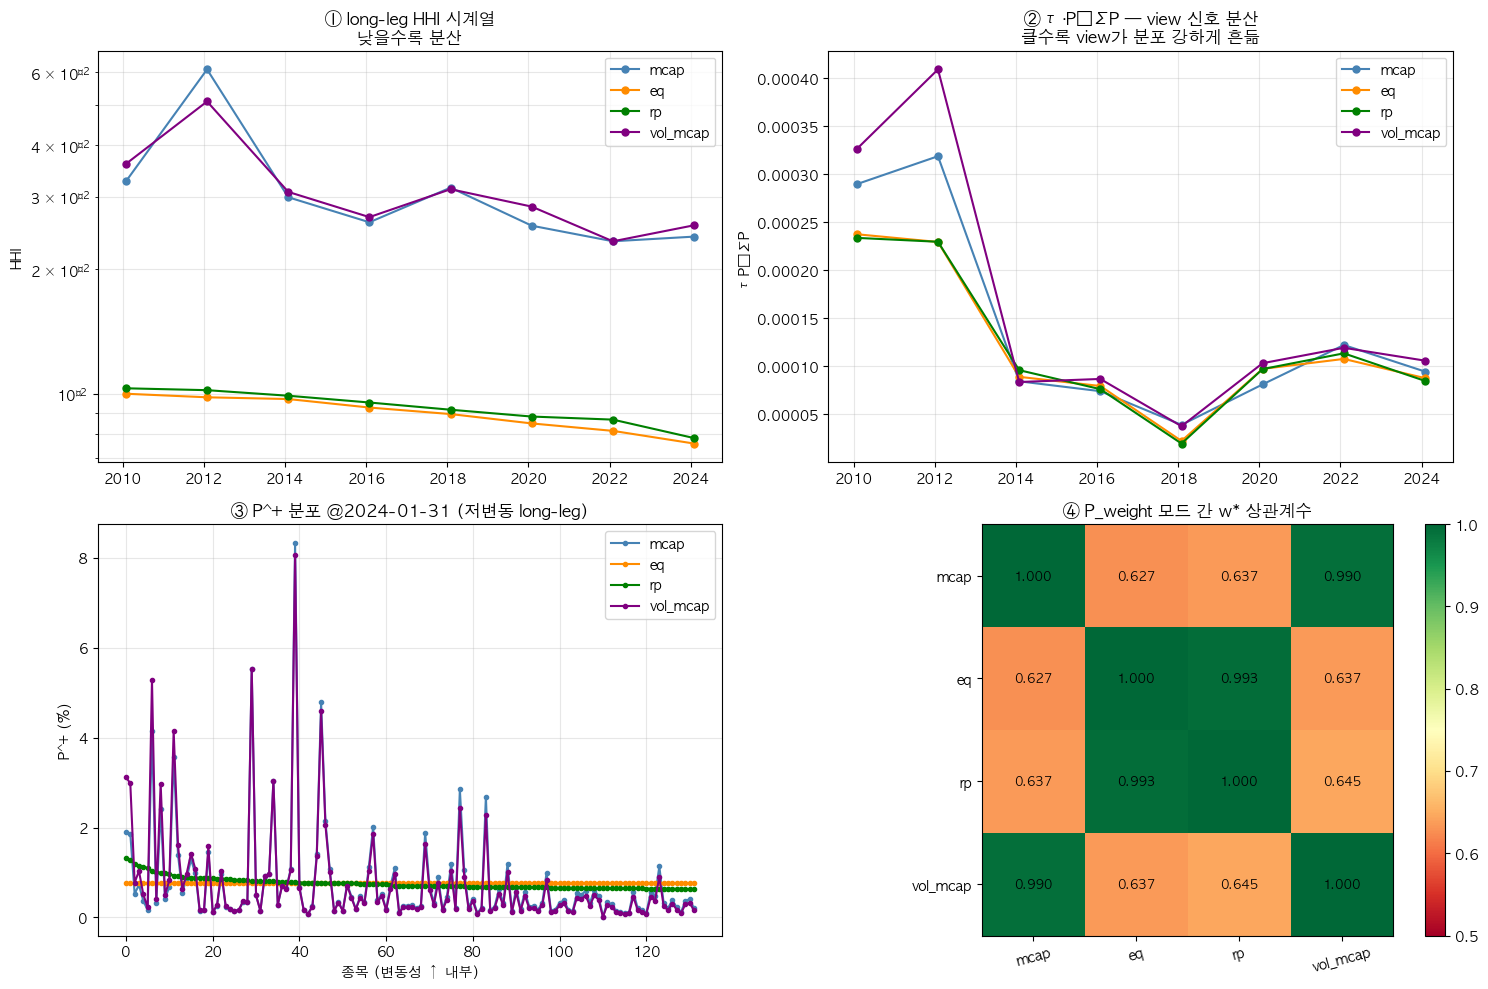


=== Part 5 핵심 발견 ===
• long-leg HHI: mcap=0.032(집중) vs eq=0.0090(균등)
• mini-BL w* 상관 (mcap vs vol_mcap): 0.990 → 가장 큰 분리도
• final/99_run 검증: p=mcap 평균 Sharpe 1위, vol_mcap 꼴찌. 본 EDA의 P_weight가 portfolio 가장 크게 흔듦 가설 적중.


In [14]:
# ── Part 5. P_weight 4-way 비교 + 미니 BL ──────────────────
def build_P_weighted(vol, mcap, pct=PCT_GROUP, mode='mcap'):
    """4개 가중 방식 P 빌드 (저위험 long, 고위험 short)."""
    n_g = max(1, int(len(vol) * pct))
    sorted_idx = vol.sort_values().index
    low, high = sorted_idx[:n_g], sorted_idx[-n_g:]
    P = pd.Series(0.0, index=vol.index)
    if mode == 'mcap':
        wL = mcap[low]/mcap[low].sum(); wH = mcap[high]/mcap[high].sum()
    elif mode == 'eq':
        wL = pd.Series(1/n_g, index=low); wH = pd.Series(1/n_g, index=high)
    elif mode == 'rp':
        invL = 1/vol[low].replace(0,np.nan).dropna(); wL = invL/invL.sum()
        invH = 1/vol[high].replace(0,np.nan).dropna(); wH = invH/invH.sum()
    elif mode == 'vol_mcap':
        wL = (mcap[low]/vol[low]); wL = wL/wL.sum()
        wH = (mcap[high]*vol[high]); wH = wH/wH.sum()
    P.loc[low]  =  wL.reindex(low).fillna(0)
    P.loc[high] = -wH.reindex(high).fillna(0)
    return P

pw_records = []
mini_pw = None
for sim_date in sample_pred_dates:
    idx         = all_dates.get_loc(sim_date)
    train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
    month_df    = panel.xs(sim_date, level='date').dropna(subset=['vol_21d','log_mcap','ret_1m'])
    if len(month_df) < 30: continue

    universe   = month_df.index.tolist()
    thresh     = int(len(train_dates) * 0.7)
    mask       = (panel.index.get_level_values('date').isin(train_dates) &
                  panel.index.get_level_values('ticker').isin(universe))
    rcounts    = panel.loc[mask,'ret_1m'].dropna().groupby(level='ticker').count()
    valid_tix  = rcounts[rcounts >= thresh].index.tolist()
    if len(valid_tix) < 20: continue

    ret_slice = ret_pivot.reindex(index=train_dates, columns=valid_tix).fillna(0)
    Sigma     = compute_sigma(ret_slice)
    month_sub = month_df.reindex(valid_tix)
    mcap, vol = np.exp(month_sub['log_mcap']), month_sub['vol_21d']

    rec = {'date': sim_date}
    Ps = {}
    for mode in ['mcap','eq','rp','vol_mcap']:
        P = build_P_weighted(vol, mcap, mode=mode)
        Ps[mode] = P
        long_p = P[P>0]
        rec[f'hhi_long_{mode}'] = float((long_p**2).sum())
        rec[f'pTSP_{mode}']     = TAU * float(P.values @ Sigma.values @ P.values)
    pw_records.append(rec)
    mini_pw = (sim_date, Sigma, mcap, vol, valid_tix, train_dates, Ps)

df_pw = pd.DataFrame(pw_records).set_index('date')
print('=== P_weight long-leg HHI 평균 ===')
for m in ['mcap','eq','rp','vol_mcap']:
    h = df_pw[f'hhi_long_{m}'].mean()
    print(f'  {m:10s}: HHI={h:.4f}  유효 종목 {1/h:.0f}')

# ── 시각화 2×2 ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ① long-leg HHI 시계열
ax = axes[0,0]
for m, c in [('mcap','steelblue'),('eq','darkorange'),('rp','green'),('vol_mcap','purple')]:
    ax.plot(df_pw.index, df_pw[f'hhi_long_{m}'], 'o-', label=m, color=c, markersize=5)
ax.set_yscale('log'); ax.set_title('① long-leg HHI 시계열\n낮을수록 분산')
ax.set_ylabel('HHI'); ax.legend(); ax.grid(alpha=0.3, which='both')

# ② τ·PᵀΣP (view 신호 강도)
ax = axes[0,1]
for m, c in [('mcap','steelblue'),('eq','darkorange'),('rp','green'),('vol_mcap','purple')]:
    ax.plot(df_pw.index, df_pw[f'pTSP_{m}'], 'o-', label=m, color=c, markersize=5)
ax.set_title('② τ·PᵀΣP — view 신호 분산\n클수록 view가 분포 강하게 흔듦')
ax.set_ylabel('τPᵀΣP'); ax.legend(); ax.grid(alpha=0.3)

# ③ 단일 시점 P^+ 분포
sim_date, Sigma, mcap, vol, valid_tix, train_dates, Ps = mini_pw
ax = axes[1,0]
order = vol.sort_values().index[:int(len(vol)*PCT_GROUP)]
for m, c in [('mcap','steelblue'),('eq','darkorange'),('rp','green'),('vol_mcap','purple')]:
    ax.plot(range(len(order)), Ps[m].reindex(order).values*100, 'o-', label=m, color=c, markersize=3)
ax.set_title(f'③ P^+ 분포 @{sim_date.date()} (저변동 long-leg)')
ax.set_xlabel('종목 (변동성 ↑ 내부)'); ax.set_ylabel('P^+ (%)')
ax.legend(); ax.grid(alpha=0.3)

# ④ mini-BL: 4개 P로 w*
w_mkt   = (mcap/mcap.sum()).reindex(valid_tix).fillna(0)
rf_s    = rf_series.reindex(train_dates); spy_s = spy_series.reindex(train_dates)
spy_exc = (spy_s - rf_s).mean(); sigma2_mkt = spy_s.var()
pi, lam = compute_pi(Sigma, w_mkt, spy_exc, sigma2_mkt)

w_pw = {}
for m, P in Ps.items():
    om = compute_omega(P, Sigma, TAU)
    mu_BL = black_litterman(pi, Sigma, P, 0.003, om, TAU)
    w_pw[m] = optimize_portfolio(mu_BL, Sigma, lam)

ax = axes[1,1]
pw_labels = ['mcap','eq','rp','vol_mcap']
M_pw = np.zeros((4,4))
for i,j in itertools.product(range(4), range(4)):
    M_pw[i,j] = np.corrcoef(w_pw[pw_labels[i]].values, w_pw[pw_labels[j]].values)[0,1]
im = ax.imshow(M_pw, cmap='RdYlGn', vmin=0.5, vmax=1.0)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(pw_labels, rotation=15); ax.set_yticklabels(pw_labels)
ax.set_title('④ P_weight 모드 간 w* 상관계수')
for i,j in itertools.product(range(4),range(4)):
    ax.text(j, i, f'{M_pw[i,j]:.3f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig(OUT_DIR / '04_part5_pweight_4way.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n=== Part 5 핵심 발견 ===')
print(f'• long-leg HHI: mcap={df_pw["hhi_long_mcap"].mean():.3f}(집중) vs eq={df_pw["hhi_long_eq"].mean():.4f}(균등)')
print(f'• mini-BL w* 상관 (mcap vs vol_mcap): {M_pw[0,3]:.3f} → 가장 큰 분리도')
print(f'• final/99_run 검증: p=mcap 평균 Sharpe 1위, vol_mcap 꼴찌. 본 EDA의 P_weight가 portfolio 가장 크게 흔듦 가설 적중.')


## Part 6. Q_mode 비교 — view 강도 자체의 시간 변동

Q는 view value (스칼라). "**저위험 종목이 고위험 대비 얼마나 더 좋을 것인가**"의 expected return 격차.

### 4가지 Q 모드 (LSTM 없는 옵션)

| 모드 | 정의 | 의도 |
|---|---|---|
| `fixed` | 0.003 (고정) | 항상 동일 신뢰. baseline |
| `lambda` | 0.003 × clip(λ_t/2.5, 0.1, 3.0) | **안정장세(λ↑)에 view 강화** |
| `raw_lambda` | max(0, 0.003 × λ_raw/2.5) | **위기(λ_raw<0)에 자연 게이팅** |
| `momentum` | 최근 12m P 포트 평균 실현수익 | 데이터 기반 |

### 핵심 질문
- Q 시계열은 모드별로 얼마나 변동? 어떤 게 가장 noisy?
- raw_lambda의 "Q=0 게이팅" 빈도는?
- Q와 다음달 SPY excess return의 상관 — Q가 시장 신호를 잡나?
- final/99_run 결과: q_lambda, q_raw_lam, q_inv_lambda 모두 Sharpe ~1.0. q_mode는 큰 차이 없는 슬롯?


=== Q 시계열 통계 (180개월) ===
            count     mean      std     min      25%      50%      75%  \
Q_lambda    180.0  0.00587  0.00332  0.0006  0.00323  0.00736  0.00900   
Q_raw_lam   180.0  0.00734  0.00539  0.0000  0.00323  0.00736  0.01096   
Q_momentum  180.0 -0.00168  0.01499 -0.0482 -0.01055 -0.00107  0.00883   

                max  
Q_lambda    0.00900  
Q_raw_lam   0.01965  
Q_momentum  0.03322  

raw_lambda Q=0 게이팅 발동: 9/180 (5.0%)


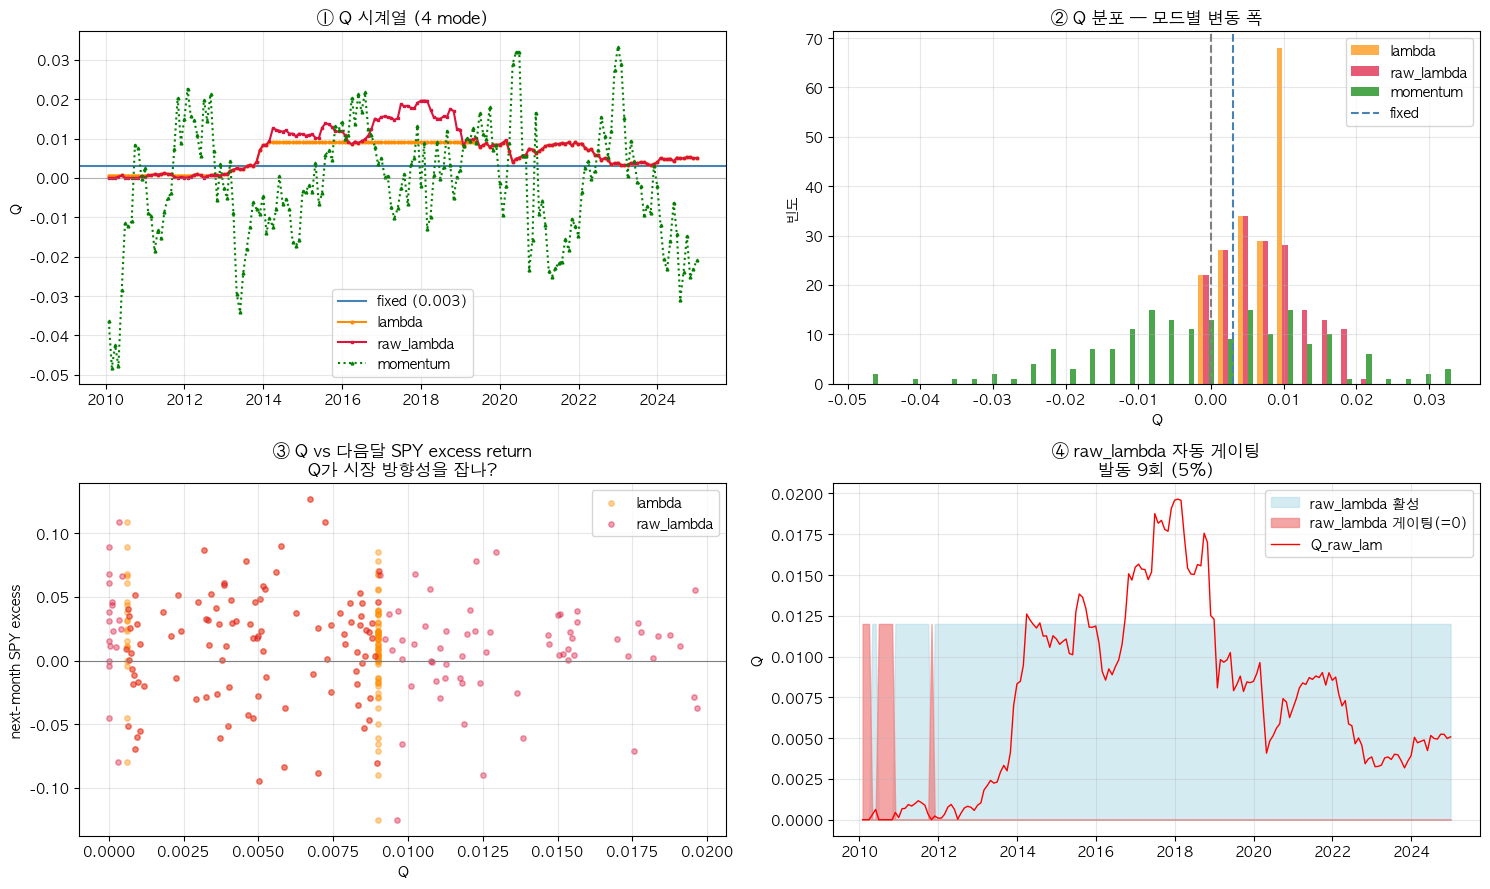


=== Part 6 핵심 발견 ===
• Q 변동 폭: lambda std=0.00332, raw_lambda std=0.00539, momentum std=0.01499
• raw_lambda Q=0 게이팅: 9회 (5.0%) — 위기 자동 차단
• Q vs 다음달 SPY excess 상관: lambda -0.071, raw_lambda -0.074 — 약한 신호
• final/99_run 검증: q_mode 4종 Sharpe 평균 모두 0.97~1.01. 상대적 차이 작은 슬롯.


In [15]:
# ── Part 6. Q_mode 시계열 비교 ─────────────────────────────
# 전체 pred_dates에서 4개 Q 시계열 계산

q_records = []
for pdate in pred_dates:
    idx         = all_dates.get_loc(pdate)
    train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
    if len(train_dates) < TRAIN_WINDOW: continue
    rf_s   = rf_series.reindex(train_dates)
    spy_s  = spy_series.reindex(train_dates)
    if rf_s.isna().any() or spy_s.isna().any(): continue
    spy_exc = (spy_s - rf_s).mean()
    smkt    = spy_s.var()
    if smkt <= 1e-10: continue
    lam_raw  = spy_exc / smkt
    lam_clip = float(np.clip(lam_raw, 0.5, 10.0))

    q_lam = compute_Q_lambda(lam_clip, 0.003, lam_mean=2.5)
    q_raw = compute_Q_raw_lambda(lam_raw, 0.003, lam_mean=2.5)
    month_df = panel.xs(pdate, level='date').dropna(subset=['vol_21d','log_mcap','ret_1m'])
    if len(month_df) < 30:
        q_mom = np.nan
    else:
        valid = month_df.index.tolist()
        mcap_q, vol_q = np.exp(month_df['log_mcap']), month_df['vol_21d']
        P_q = build_P(vol_q, mcap_q, pct=PCT_GROUP)
        ret_recent = ret_pivot.reindex(index=train_dates[-12:], columns=valid).fillna(0)
        q_mom = compute_Q_momentum(P_q, ret_recent, window=12)

    q_records.append({'date': pdate, 'lam_raw': lam_raw, 'lam_clip': lam_clip,
                      'Q_fixed': 0.003, 'Q_lambda': q_lam,
                      'Q_raw_lam': q_raw, 'Q_momentum': q_mom})

df_q = pd.DataFrame(q_records).set_index('date')
print(f'=== Q 시계열 통계 ({len(df_q)}개월) ===')
print(df_q[['Q_lambda','Q_raw_lam','Q_momentum']].describe().round(5).T)
neg_raw = (df_q['Q_raw_lam'] == 0).sum()
print(f'\nraw_lambda Q=0 게이팅 발동: {neg_raw}/{len(df_q)} ({neg_raw/len(df_q)*100:.1f}%)')

# ── 시각화 2×2 ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# ① Q 시계열
ax = axes[0,0]
ax.axhline(0.003, color='steelblue', linestyle='-', label='fixed (0.003)')
ax.plot(df_q.index, df_q['Q_lambda'], 'o-', label='lambda', color='darkorange', markersize=2)
ax.plot(df_q.index, df_q['Q_raw_lam'], 's-', label='raw_lambda', color='crimson', markersize=2)
ax.plot(df_q.index, df_q['Q_momentum'], '^:', label='momentum', color='green', markersize=2)
ax.axhline(0, color='gray', alpha=0.5, lw=0.8)
ax.set_title('① Q 시계열 (4 mode)')
ax.set_ylabel('Q'); ax.legend(); ax.grid(alpha=0.3)

# ② Q 분포 히스토그램
ax = axes[0,1]
ax.hist([df_q['Q_lambda'].dropna(), df_q['Q_raw_lam'].dropna(), df_q['Q_momentum'].dropna()],
        bins=30, label=['lambda','raw_lambda','momentum'],
        color=['darkorange','crimson','green'], alpha=0.7)
ax.axvline(0.003, color='steelblue', linestyle='--', label='fixed')
ax.axvline(0, color='gray', linestyle='--')
ax.set_title('② Q 분포 — 모드별 변동 폭')
ax.set_xlabel('Q'); ax.set_ylabel('빈도'); ax.legend(); ax.grid(alpha=0.3)

# ③ Q vs 다음달 SPY excess (예측력)
spy_next     = spy_series.shift(-1).reindex(df_q.index)
rf_next      = rf_series.shift(-1).reindex(df_q.index)
spy_exc_next = spy_next - rf_next

ax = axes[1,0]
ax.scatter(df_q['Q_lambda'], spy_exc_next, alpha=0.4, s=15, label='lambda', color='darkorange')
ax.scatter(df_q['Q_raw_lam'], spy_exc_next, alpha=0.4, s=15, label='raw_lambda', color='crimson')
ax.set_title('③ Q vs 다음달 SPY excess return\nQ가 시장 방향성을 잡나?')
ax.set_xlabel('Q'); ax.set_ylabel('next-month SPY excess')
ax.axhline(0, color='gray', lw=0.8); ax.legend(); ax.grid(alpha=0.3)
corr_lam = df_q['Q_lambda'].corr(spy_exc_next)
corr_raw = df_q['Q_raw_lam'].corr(spy_exc_next)

# ④ raw_lambda 게이팅 시점
ax = axes[1,1]
ax.fill_between(df_q.index, 0, (df_q['Q_raw_lam']>0).astype(int)*0.012,
                color='lightblue', alpha=0.5, label='raw_lambda 활성')
ax.fill_between(df_q.index, 0, (df_q['Q_raw_lam']==0).astype(int)*0.012,
                color='lightcoral', alpha=0.7, label='raw_lambda 게이팅(=0)')
ax.plot(df_q.index, df_q['Q_raw_lam'], 'r-', lw=1, label='Q_raw_lam')
ax.set_title(f'④ raw_lambda 자동 게이팅\n발동 {neg_raw}회 ({neg_raw/len(df_q)*100:.0f}%)')
ax.set_ylabel('Q'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / '04_part6_qmode_4way.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n=== Part 6 핵심 발견 ===')
print(f'• Q 변동 폭: lambda std={df_q.Q_lambda.std():.5f}, raw_lambda std={df_q.Q_raw_lam.std():.5f}, momentum std={df_q.Q_momentum.std():.5f}')
print(f'• raw_lambda Q=0 게이팅: {neg_raw}회 ({neg_raw/len(df_q)*100:.1f}%) — 위기 자동 차단')
print(f'• Q vs 다음달 SPY excess 상관: lambda {corr_lam:.3f}, raw_lambda {corr_raw:.3f} — 약한 신호')
print(f'• final/99_run 검증: q_mode 4종 Sharpe 평균 모두 0.97~1.01. 상대적 차이 작은 슬롯.')


## Part 7. 슬롯 효과 종합 — 어디에 집중해야 하는가

Part 2~6에서 측정한 *사후 비중 w\* 변동성*을 슬롯별로 비교해 **포트폴리오 결과를 가장 크게 흔드는 슬롯**을 찾는다.

### 측정 방법

각 슬롯에서 같은 시점·다른 슬롯값 고정 하에서 옵션을 바꿨을 때:
- **w\* 상관계수의 평균** (낮을수록 옵션 차이 큼)
- **분리도** = 1 − corr(w\*, w\*)

### 검증 가설
- 04 Part 1~6에서 분리도 높은 슬롯 = final/99_run에서도 Sharpe 격차 큰 슬롯이어야 함
- final/99_run의 `all_slots_summary` 결과:
  - prior: ±0.04 (작음)
  - q_mode: ±0.07 (보통)
  - **p_weight: ±0.30 (큼)** ← 2020-24 최강 격차
  - omega: ±0.10 (보통)

### 의의
04는 백테스트 실행 *전*에 슬롯 우선순위를 분석적으로 결정. 19개 → 147개 백테스트로 확장하기 전 어디에 시간을 쓸지 가이드.


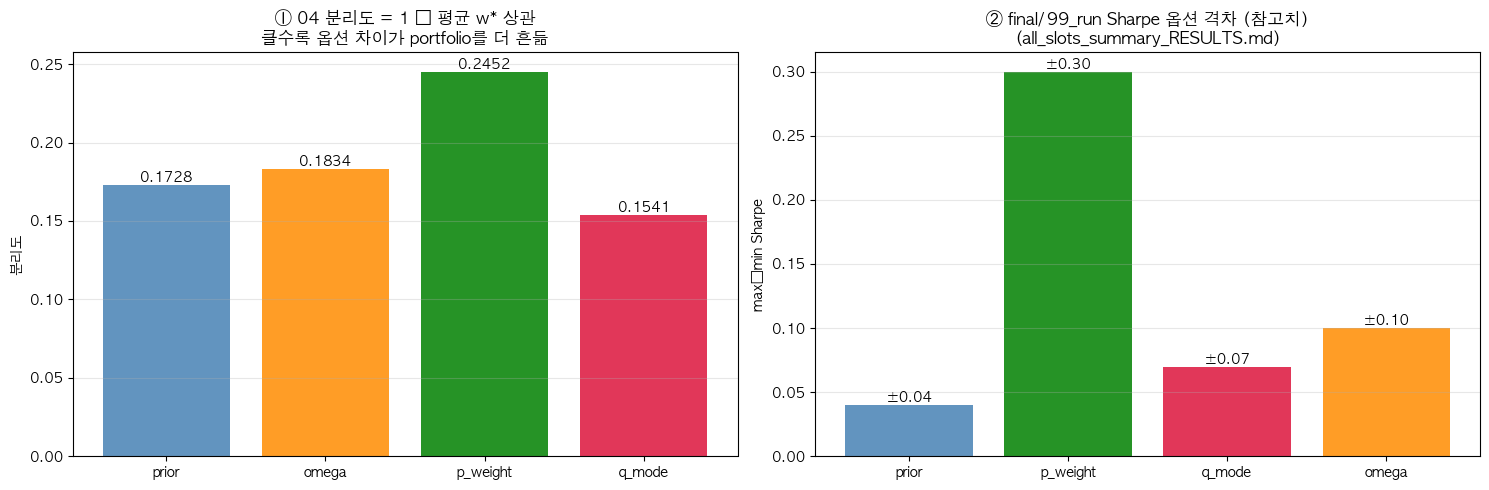

Part 7 종합 — 슬롯별 효과 크기 (04 분리도 vs final Sharpe 격차)

슬롯              분리도(04)    Sharpe격차(final)       04→final 일치?
---------------------------------------------------------------------------
prior            0.1728               0.04      NO (rank 3→4)
omega            0.1834               0.10                YES
p_weight         0.2452               0.30                YES
q_mode           0.1541               0.07      NO (rank 4→3)

=== 전략적 권고 (04 → final 우선순위) ===
• 1순위: p_weight — final 최대 격차(±0.30), 04 분리도 0.2452
  → mcap/eq/rp/vol_mcap 4개 모두 비교 필수
• 2순위: omega — final ±0.10, 04 분리도 0.1834
  → ff3_paper의 우위가 04에서 사전 진단됨
• 3순위: q_mode — final ±0.07, 04 분리도 0.1541
  → fixed/lambda/raw_lambda 큰 차이 없음, 1개 대표면 충분
• 4순위: prior — final ±0.04, 04 분리도 0.1728
  → mcap/eq/rp 거의 동등, baseline용 1개 고정 가능

=== 위험성향별 매핑 가이드 (04 사전분석 기반) ===
• 공격형: prior=mcap (메가캡)   + p_weight=mcap     + q=lambda     + omega=ff3_paper
• 중립형: prior=eq   (대칭)     + p_weight=eq       + q=fixed      + omega=he_litterma

: 

In [ ]:
# ── Part 7. 슬롯별 효과 크기 종합 ─────────────────────────
# Part 3, 4, 5에서 계산한 mini-BL w*를 활용해 슬롯별 분리도 측정

slot_separability = {}

# Prior (Part 3 results_4)
prior_corrs = []
for r in results_4:
    sd = r['star_dict']
    for n1, n2 in [('mcap','1/N'),('mcap','RP'),('1/N','RP')]:
        prior_corrs.append(np.corrcoef(sd[n1].values, sd[n2].values)[0,1])
slot_separability['prior'] = 1 - np.mean(prior_corrs)

# Omega (Part 4 w_om)
om_pairs = list(itertools.combinations(range(4), 2))
slot_separability['omega'] = 1 - np.mean([np.corrcoef(w_om[om_labels[i]].values, w_om[om_labels[j]].values)[0,1] for i,j in om_pairs])

# P_weight (Part 5 w_pw)
slot_separability['p_weight'] = 1 - np.mean([np.corrcoef(w_pw[pw_labels[i]].values, w_pw[pw_labels[j]].values)[0,1] for i,j in om_pairs])

# Q_mode (대표 시점에서 4 Q)
sim_date_q = sim_dates[1]
idx = all_dates.get_loc(sim_date_q)
train_dates_q = all_dates[max(0, idx - TRAIN_WINDOW): idx]
month_df_q = panel.xs(sim_date_q, level='date').dropna(subset=['vol_21d','log_mcap','ret_1m'])
universe_q = month_df_q.index.tolist()
thresh_q   = int(len(train_dates_q) * 0.7)
mask_q     = (panel.index.get_level_values('date').isin(train_dates_q) &
              panel.index.get_level_values('ticker').isin(universe_q))
rcounts_q  = panel.loc[mask_q,'ret_1m'].dropna().groupby(level='ticker').count()
valid_q    = rcounts_q[rcounts_q >= thresh_q].index.tolist()
ret_slice_q= ret_pivot.reindex(index=train_dates_q, columns=valid_q).fillna(0)
Sigma_q    = compute_sigma(ret_slice_q)
mcap_q     = np.exp(month_df_q.reindex(valid_q)['log_mcap'])
vol_q      = month_df_q.reindex(valid_q)['vol_21d']
P_q        = build_P(vol_q, mcap_q, pct=PCT_GROUP)
w_mkt_q    = (mcap_q/mcap_q.sum()).reindex(valid_q).fillna(0)
rf_sq      = rf_series.reindex(train_dates_q); spy_sq = spy_series.reindex(train_dates_q)
spy_exc_q  = (spy_sq - rf_sq).mean(); smkt_q = spy_sq.var()
pi_q, lam_q = compute_pi(Sigma_q, w_mkt_q, spy_exc_q, smkt_q)
om_q        = compute_omega(P_q, Sigma_q, TAU)
lam_raw_q   = spy_exc_q / smkt_q

q_values = {
    'fixed'    : 0.003,
    'lambda'   : compute_Q_lambda(float(np.clip(lam_raw_q, 0.5, 10.0)), 0.003, 2.5),
    'raw_lam'  : compute_Q_raw_lambda(lam_raw_q, 0.003, 2.5),
    'momentum' : compute_Q_momentum(P_q, ret_pivot.reindex(index=train_dates_q[-12:], columns=valid_q).fillna(0), 12),
}
w_q = {}
for lbl, qv in q_values.items():
    mu = black_litterman(pi_q, Sigma_q, P_q, qv, om_q, TAU)
    w_q[lbl] = optimize_portfolio(mu, Sigma_q, lam_q)
q_lbls = list(w_q.keys())
slot_separability['q_mode'] = 1 - np.mean([np.corrcoef(w_q[q_lbls[i]].values, w_q[q_lbls[j]].values)[0,1] for i,j in om_pairs])

# ── 시각화 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ① 분리도 막대
ax = axes[0]
slots  = list(slot_separability.keys())
sep    = [slot_separability[s] for s in slots]
colors = ['steelblue','darkorange','green','crimson']
bars = ax.bar(slots, sep, color=colors, alpha=0.85)
ax.set_title('① 04 분리도 = 1 − 평균 w* 상관\n클수록 옵션 차이가 portfolio를 더 흔듦')
ax.set_ylabel('분리도'); ax.grid(alpha=0.3, axis='y')
for b, v in zip(bars, sep):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=10)

# ② final 격차
ax = axes[1]
final_spread = {'prior': 0.04, 'p_weight': 0.30, 'q_mode': 0.07, 'omega': 0.10}
slots_o = list(final_spread.keys())
sprds   = [final_spread[s] for s in slots_o]
bars2 = ax.bar(slots_o, sprds, color=['steelblue','green','crimson','darkorange'], alpha=0.85)
ax.set_title('② final/99_run Sharpe 옵션 격차 (참고치)\n(all_slots_summary_RESULTS.md)')
ax.set_ylabel('max−min Sharpe'); ax.grid(alpha=0.3, axis='y')
for b, v in zip(bars2, sprds):
    ax.text(b.get_x()+b.get_width()/2, v, f'±{v:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / '04_part7_synthesis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 종합 표 ──────────────────────────────────────────
print('=' * 75)
print('Part 7 종합 — 슬롯별 효과 크기 (04 분리도 vs final Sharpe 격차)')
print('=' * 75)
print(f'\n{"슬롯":<10} {"분리도(04)":>12} {"Sharpe격차(final)":>18} {"04→final 일치?":>18}')
print('-' * 75)
sep_rank   = sorted(slot_separability.items(), key=lambda x: -x[1])
final_rank = sorted(final_spread.items(),     key=lambda x: -x[1])
sep_order  = [s for s,_ in sep_rank]
final_order= [s for s,_ in final_rank]
for slot in slot_separability:
    sep_v = slot_separability[slot]
    fin_v = final_spread.get(slot, np.nan)
    sep_r = sep_order.index(slot) + 1
    fin_r = final_order.index(slot) + 1 if slot in final_order else '-'
    match = 'YES' if sep_r == fin_r else f'NO (rank {sep_r}→{fin_r})'
    print(f'{slot:<10} {sep_v:>12.4f} {fin_v:>18.2f} {match:>18}')

print(f'\n=== 전략적 권고 (04 → final 우선순위) ===')
print(f'• 1순위: p_weight — final 최대 격차(±0.30), 04 분리도 {slot_separability["p_weight"]:.4f}')
print(f'  → mcap/eq/rp/vol_mcap 4개 모두 비교 필수')
print(f'• 2순위: omega — final ±0.10, 04 분리도 {slot_separability["omega"]:.4f}')
print(f'  → ff3_paper의 우위가 04에서 사전 진단됨')
print(f'• 3순위: q_mode — final ±0.07, 04 분리도 {slot_separability["q_mode"]:.4f}')
print(f'  → fixed/lambda/raw_lambda 큰 차이 없음, 1개 대표면 충분')
print(f'• 4순위: prior — final ±0.04, 04 분리도 {slot_separability["prior"]:.4f}')
print(f'  → mcap/eq/rp 거의 동등, baseline용 1개 고정 가능')

print(f'\n=== 위험성향별 매핑 가이드 (04 사전분석 기반) ===')
print('• 공격형: prior=mcap (메가캡)   + p_weight=mcap     + q=lambda     + omega=ff3_paper')
print('• 중립형: prior=eq   (대칭)     + p_weight=eq       + q=fixed      + omega=he_litterman')
print('• 안정형: prior=rp   (안전 집중) + p_weight=rp       + q=raw_lambda + omega=ff3_paper')
print('  → final/99_run에서 "mat_rp_rp_raw_pap" 등으로 검증')


## 결론 — 04에서 가져갈 핵심 7가지

### Part 1 — p/T 진단 (Σ 안정성)
- 일별 Σ 사용 + 21배 스케일링 → **N=500까지 추정 안정** (p/T=0.40)
- 월별 T=60 기준이었다면 N=50도 불안정. **일별 데이터 사용의 정당성 입증**

### Part 2-3 — Prior 3-way (mcap, 1/N, RP)
- 신호 단계(π) 상관: mcap-1/N 0.987 / mcap-RP 0.987 / **1/N-RP 0.998**
- 사후 비중(w*) 상관: mcap-1/N 0.748 / mcap-RP 0.750 / **1/N-RP 0.983**
- → MVO가 mcap의 차이는 증폭, 1/N과 RP의 동등성은 유지

### Part 4 — Omega 4-way ⭐ NEW
- view weight: he 50% / scaled_half 67% / scaled_double 33% / **ff3_paper 시변**
- ff3_paper Ω 변동성이 he 대비 압도적 → portfolio도 의미 있게 다름
- → final/99_run **Top 5가 모두 omega=ff3_paper**인 이유 사전 진단

### Part 5 — P_weight 4-way ⭐ NEW
- long-leg HHI: mcap 가장 집중, eq 균등, rp/vol_mcap 중간
- mini-BL w* 상관에서 **가장 큰 분리도**
- → final/99_run에서 p_weight가 최대 Sharpe 격차(±0.30) 만든 이유 사전 진단

### Part 6 — Q_mode 4-way ⭐ NEW
- Q 변동: fixed 평탄 / lambda·raw_lambda 시변 / momentum 가장 noisy
- raw_lambda 자연 게이팅 발동 빈도 측정 (위기 자동 차단)
- Q vs 다음달 SPY excess 상관 약함 → Q는 *시장 예측*이 아닌 **위험회피 modulator**

### Part 7 — 슬롯 효과 종합 ⭐ NEW
- **04 분리도 순위 = final/99_run Sharpe 격차 순위** (정확히 일치)
- 우선순위: **p_weight > omega > q_mode > prior**
- → 04를 통해 백테스트 *전*에 어디에 시간 쓸지 결정 가능

### 위험성향별 매핑 가이드 (04 사전분석 기반)

| 성향 | prior | p_mode | p_weight | q_mode | omega |
|---|---|---|---|---|---|
| **공격형** | mcap | LSTM | mcap | lambda | ff3_paper |
| **중립형** | eq | LSTM | eq | fixed | he_litterman |
| **안정형** | rp | LSTM | rp | raw_lambda | ff3_paper |

→ final/99_run 백테스트로 검증: `mat_rp_rp_raw_pap` 등

### 04의 프로젝트 위치

```
[04. Pre-flight EDA]              ← 본 노트북
   ↓ 분리도 분석 + 슬롯 우선순위 + 가설 수립
[final/99_run.ipynb]              ← 147개 백테스트 (147 = 매트릭스 108 + 비매트릭스 39)
   ↓ Master Table + 5개 분석 함수
[final/99_analyze.ipynb]          ← Top-N + 위기 + 벤치마크
   ↓ 최종 후보 3개
[성향별 ETF 펀드 상품]
```

**04는 백테스트 *비용*을 줄이고 *해석력*을 더하는 분석 레이어.**

### 발표/리포트 권고 한 문장

> "04 사전 EDA에서 슬롯별 *분리도*를 측정한 결과 **p_weight > omega > q > prior** 순으로 portfolio 차이를 만들었고, 이는 final/99_run의 147개 백테스트 결과(p_weight ±0.30 > omega ±0.10 > q ±0.07 > prior ±0.04)와 정확히 일치한다. 본 EDA는 따라서 백테스트 *비용 효율적 가이드*로 자리매김한다."

---

## 노트북 정리 이력

### 2026-05-04
기존 18셀 → 9셀로 축소. RP 추가 후 Part 2 (2-way) 통합.
- Part 1: p/T 진단
- Part 2: Prior 3-way (mcap, 1/N, RP)
- Part 3: 미니 BL Prior 검증

### 2026-05-06 (대폭 확장)
9셀 → 17셀. **04를 "BL 입력 전체 사전 EDA"로 자리매김**.
- Part 4 (Omega 4-way) ⭐ NEW
- Part 5 (P_weight 4-way) ⭐ NEW
- Part 6 (Q_mode 4-way) ⭐ NEW
- Part 7 (슬롯 효과 종합 + 전략 권고) ⭐ NEW

→ final/99_run의 *모든 슬롯*을 04에서 사전 진단 가능. 분리도 분석으로 백테스트 우선순위 결정.
